# __EVOLUCIÓN DEL PRECIO DE LA VIVIENDA EN PUENTE DE VALLECAS POR DISTRITO__

---

Realizaremos un EDA simple para ver la evolucion temporal del precio de la vivienda en el distrito de Puente de Vallecas (Madrid) entre los años 2007 y 2025 utilizando los datos obtenidos del portal público del [Ayuntamiento de Madrid](https://servpub.madrid.es/CSEBD_WBINTER/seleccionSerie.html?numSerie=0504020100060).


Importamos los sospechosos habituales.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Importamos los datos obtenidos del portal.

In [2]:
df_nuevas = pd.read_csv('data/clean/puente_nuevas_raw.csv', delimiter = ';')
df_usadas = pd.read_csv('data/clean/puente_usadas_raw.csv', delimiter = ';')
df_total = pd.read_csv('data/clean/puente_total_raw.csv', delimiter = ';')

FileNotFoundError: [Errno 2] No such file or directory: 'data/clean/puente_nuevas_raw.csv'

Vamos a realizar una limpieza rápida de los datos para poder trabajar en nuestros gráficos.

In [3]:
# Nos quitamos de enmedio la columna barrio que no nos aporta información
df_total.drop(['Barrio'],axis='columns', inplace=True)
df_usadas.drop(['Barrio'],axis='columns', inplace=True)
df_nuevas.drop(['Barrio'],axis='columns', inplace=True)

# Creamos los dataframes en formato largo
melted_df_total = df_total.melt(id_vars=['Distrito'],
                    var_name='Year', value_name='€_m2')
melted_df_usadas = df_usadas.melt(id_vars=['Distrito'],
                    var_name='Year', value_name='€_m2')
melted_df_nuevas = df_nuevas.melt(id_vars=['Distrito'],
                    var_name='Year', value_name='€_m2')

NameError: name 'df_total' is not defined

In [4]:
# Para cada dataframe, reemplazamos en la columna '€_m2' los carácteres necesarios para poder transformar la columna en una de tipo float para poder graficar
melted_df_total['€_m2'] = melted_df_total['€_m2'].str.replace('.', '')
melted_df_total['€_m2'] = melted_df_total['€_m2'].str.replace(',', '.')
melted_df_total['€_m2'] = melted_df_total['€_m2'].str.replace('-', '0')

melted_df_usadas['€_m2'] = melted_df_usadas['€_m2'].str.replace('.', '')
melted_df_usadas['€_m2'] = melted_df_usadas['€_m2'].str.replace(',', '.')
melted_df_usadas['€_m2'] = melted_df_usadas['€_m2'].str.replace('-', '0')

melted_df_nuevas['€_m2'] = melted_df_nuevas['€_m2'].str.replace('.', '')
melted_df_nuevas['€_m2'] = melted_df_nuevas['€_m2'].str.replace(',', '.')
melted_df_nuevas['€_m2'] = melted_df_nuevas['€_m2'].str.replace('-', '0')

NameError: name 'melted_df_total' is not defined

In [5]:
# Usamos astype para cambiar el tipo de la columna '€_m2' a float
melted_df_total = melted_df_total.astype({'Distrito': str,
                                           'Year': str,
                                           '€_m2': float
                                          })
melted_df_usadas = melted_df_usadas.astype({'Distrito': str,
                                           'Year': str,
                                           '€_m2': float
                                          })
melted_df_nuevas = melted_df_nuevas.astype({'Distrito': str,
                                           'Year': str,
                                           '€_m2': float
                                          })

NameError: name 'melted_df_total' is not defined

In [84]:
#Reemplazamos los 0 de la columna €_m2 por NaN ya que no conocemos esos datos
melted_df_total.replace(0,np.nan)
melted_df_usadas.replace(0,np.nan)
melted_df_nuevas.replace(0,np.nan)

,Distrito,Year,€_m2
0,Puente de Vallecas,2007,3520.66
1,Entrevías,2007,NaN
2,San Diego,2007,NaN
3,Palomeras Bajas,2007,NaN
4,Palomeras Sureste,2007,NaN
...,...,...,...
121,San Diego,2024,2629.51
122,Palomeras Bajas,2024,2387.19
123,Palomeras Sureste,2024,2310.02
124,Portazgo,2024,2103.77


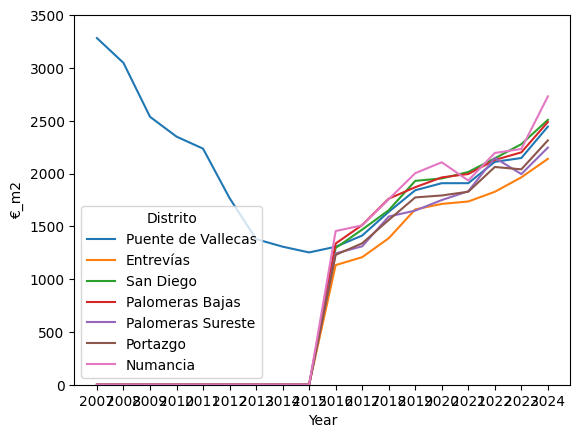

In [85]:
sns.lineplot(melted_df_total, x='Year', y='€_m2', hue ='Distrito')
plt.ylim(0, 3500)
plt.show()

Text(0.5, 1.0, 'Vivienda Usada')

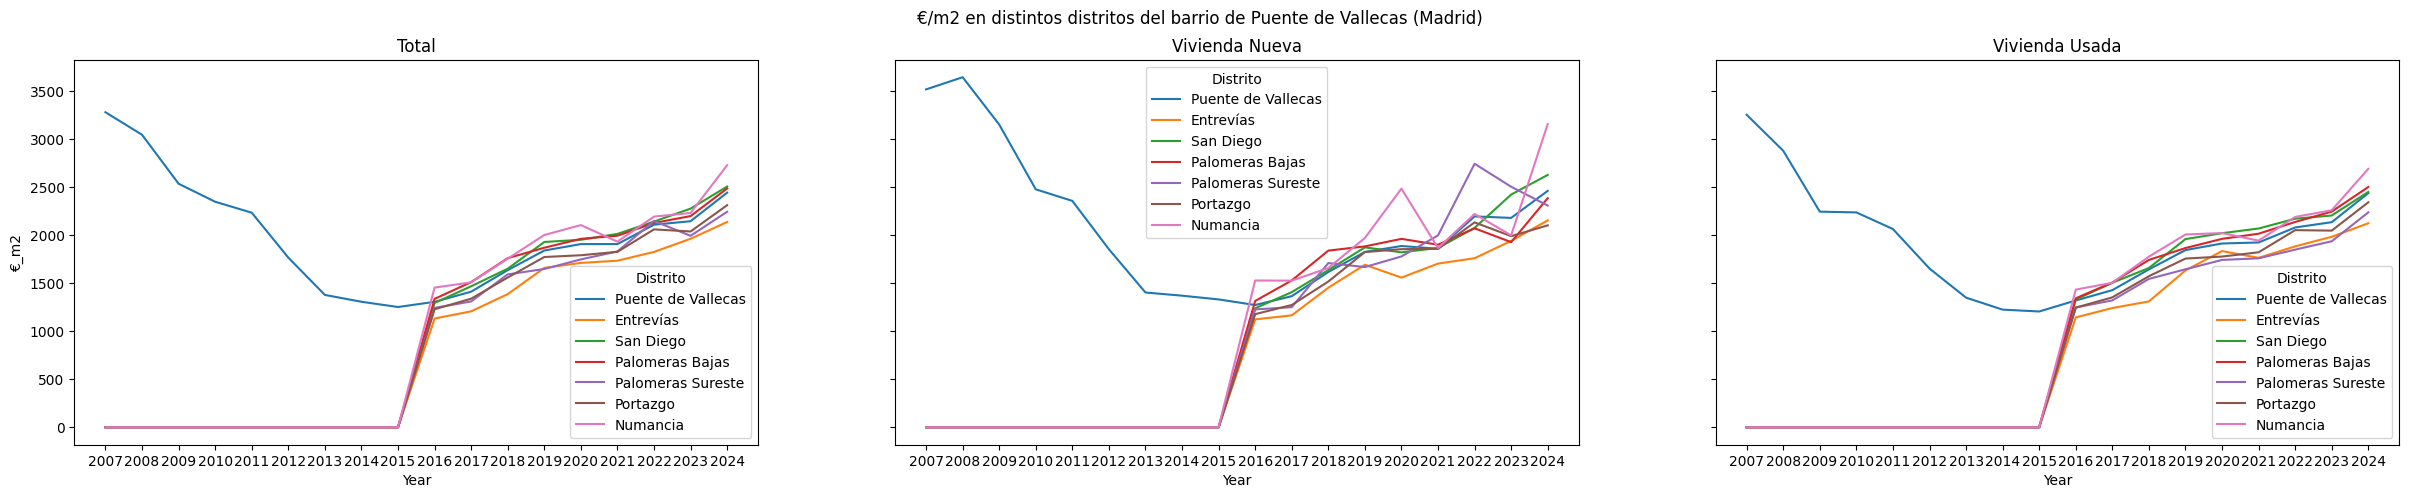

In [86]:
fig, axes = plt.subplots(1, 3, figsize=(30, 5), sharey=True)
fig.suptitle('€/m2 en distintos distritos del barrio de Puente de Vallecas (Madrid)')

# Total
sns.lineplot(ax=axes[0], data = melted_df_total, x = 'Year', y = '€_m2', hue ='Distrito')
axes[0].set_title('Total')

# Nueva
sns.lineplot(ax=axes[1], data = melted_df_nuevas, x = 'Year', y = '€_m2', hue ='Distrito')
axes[1].set_title('Vivienda Nueva')

# Usada
sns.lineplot(ax=axes[2], data = melted_df_usadas, x = 'Year', y = '€_m2', hue ='Distrito')
axes[2].set_title('Vivienda Usada')


# __GRAFICO INTERACTIVO CON BOKEH__

Para hacer un estudio más profundo, necesitamos acceso a los datos desde la propia gráfica. Esto implica que tenemos que intentar construir el gráfico de la manera más interactiva posible para poder ver como se comportan los datos. Utilizaremos la librería bokeh que seguro nos da más posibilidades a la hora de trabajar con estos datos.

Primero, vamos a integrar todos los dataframes en un único DataFrame que nos permita trabajar de una manera más sencilla solo con las columnas.

In [138]:
# Combinar usando los índices de ambos DataFrames
df_merged_interm = pd.merge(melted_df_total, melted_df_nuevas, left_index=True, right_index=True, how='left')
df_merged = pd.merge(df_merged_interm, melted_df_usadas, left_index=True, right_index=True, how='left')

In [139]:
#Eliminamos las columnas que se repiten al hacer el merged
df_merged = df_merged.drop(['Distrito_y','Year_y','Distrito','Year'], axis = 1)


In [140]:
#Renombramos las columnas de manera correcta
df = df_merged.rename(columns={'Distrito_x':'distrito', 
                               'Year_x':'year',
                               '€_m2_x':'price_m2_total','€_m2_y':'price_m2_nuevas', '€_m2':'price_m2_usadas'})

In [141]:
# Hacemos una revisión visual del DataFrame para que no se nos pase nada
df

,distrito,year,price_m2_total,price_m2_nuevas,price_m2_usadas
0,Puente de Vallecas,2007,3282.45,3520.66,3256.39
1,Entrevías,2007,0.00,0.00,0.00
2,San Diego,2007,0.00,0.00,0.00
3,Palomeras Bajas,2007,0.00,0.00,0.00
4,Palomeras Sureste,2007,0.00,0.00,0.00
...,...,...,...,...,...
121,San Diego,2024,2508.13,2629.51,2452.35
122,Palomeras Bajas,2024,2487.89,2387.19,2503.51
123,Palomeras Sureste,2024,2245.45,2310.02,2239.13
124,Portazgo,2024,2313.93,2103.77,2344.09


In [146]:
#Exportamos a CSV los datos limpios
df.to_csv("./data/clean/vivienda_puente_agrupado.csv", index=False)